# Overfitting and Underfittin

Como en lecciones pasadas, tenemos que tener cuidadon con un desajuste o un sobreajuste de nuestro modelo para que no tenga problemas de prediccion. Para esto es que tambien regulamos el peso y el sesgo. 
Se suele graficar el aprendisaje respecto al conjunto de entrenamiento, como lo vemos en la imagen, de esa forma evaluamos como es que el modelo esta haciendo su trabajo.

![learning curve](images/learning_curve.png)

Vemos que la grafica representa una funcion de perdida midiendo el conjunto de entrenamiento y de validacion. En el conjunto total, existe informacion que llamamos señales y ruido, idealmente deberiamos contruir un modelo que sepa distinguir las señales del ruido, pero esto no es asi. Podemos hacer un truco para que el modelo pueda aprender señales a costa de aprender ruido, pero en ocaciones eso no es lo correcto y se vuelve un problema.

![underfitting and overfitting](images/over_under.png)

Por lo general, hacer este truco y graficarlo, puede indicar que hay un problema, que hay poco reconocimiento de señales o que hay mucho ruido.

## Capacity

El la capacidad de un modelo, se refiere al tamaño y complejidad de los patrones para aprender. Para las nuronas, esto lo determina que tan bien estan conectados. Puedes aumentar la capacidad de tu red haciendola mas ancha (agregando mas nodos a las capas) o haciendola mas profundas, agregando mas capas. Redes anchas son capaces de aprender mas facil, mientras que las mas profundas son capaces de reconocer patrones no lineales mas facilmente.

## Early Stopping (detencion temprana)

Recordemos que cuando las redes estan aprendiendo segun las epoca, hacer que sigan aprendiendo sin un parametro puede provocar un desajuste o sobreajuste. Podemos decirle a la red cuando parar para no provocar algo asi.

![early stop](images/early_stop.png)

In [3]:
import pandas as pd

red_wine = pd.read_csv("data/red-wine.csv")
df_train = red_wine.sample(frac = 0.7, random_state = 0)
df_valid = red_wine.drop(df_train.index)

max_ = df_train.max(axis = 0)
min_ = df_train.min(axis = 0)
df_train = (df_train - min_) / (max_ - min_)
df_valid = (df_valid - min_) / (max_ - min_)

# desplegamos las funciones
X_train = df_train.drop('quality', axis = 1)
X_valid = df_valid.drop('quality', axis = 1)
y_train = df_train['quality']
y_valid = df_valid['quality']

In [5]:
from tensorflow import keras
from tensorflow.keras import layers, callbacks

early_stopping = callbacks.EarlyStopping(
    min_delta = 0.001,
    patience = 20,
    restore_best_weights = True
)

model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=[11]),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(1)
])
model.compile(
    optimizer = 'adam',
    loss = 'mae'
)

C:\Users\CDWLu\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Axes: >

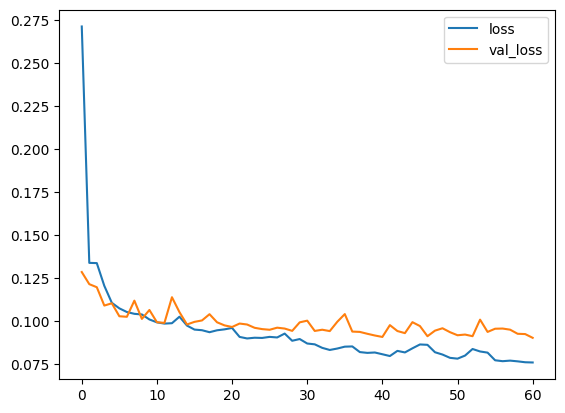

In [6]:
history = model.fit(
    X_train, y_train,
    validation_data = (X_valid, y_valid),
    batch_size = 256,
    epochs = 500,
    callbacks = [early_stopping],
    verbose = 0
)
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()

In [7]:
print("minimum validation loss: {}".format(history_df['val_loss'].min()))

minimum validation loss: 0.09008239954710007


Como vemos, las epocas pararon en 60.